# The CTHRC1⁺ pathologic fibroblast and the matrix-stiffening niche in pulmonary fibrosis

Our model of EGFR-mutant NSCLC drug tolerance assumes a stiff, fibrotic microenvironment that activates mechanosensing (FAK/AKT) and shifts cells toward a fast-cycling, drug-tolerant state. Before testing that in tumors (v2), v1 asks a prerequisite question in fibrotic lung itself, "which cells build the stiff niche, and what program do they carry?"

scRNA-seq sees mRNA, not phospho-signaling, so we look for the transcriptional response of the
stiffening machinery, collagens, crosslinkers, and the pathologic-fibroblast markers CTHRC1 /
POSTN / COMP.

**TL;DR:** the Tsukui CTHRC1⁺ pathologic fibroblast is recovered in reprocessed
human data, it expands in fibrosis while homeostatic alveolar fibroblasts contract
(composition), and the fibroblast lineage itself up-regulates the stiffening program
(cell-intrinsic)

## 2: Pipeline (raw → biology)

Snakemake workflow, per-rule conda envs, `{sample}`-parallel. Stages:

1. **Ingest** - SCEA MatrixMarket → per-donor `.h5ad`; transpose to cells×genes, gene symbols via
   mygene (≈77 %; all signature genes resolved), join the design TSV for condition + donor.
   *(Note: SCEA counts are fractional; multimapping reads split as 0.5, handled downstream.)*
2. **QC** - per donor; fixed floors (≥300 genes, ≤20 % mito; MAD was a no-op on SCEA's
   pre-called cells) + Scrublet (doublets ~0 %, expected for a sorted dataset).
3. **Normalize / integrate** - log1p CP10k, seurat HVGs, PCA, Harmony on `donor_id`.
4. **Cluster / annotate** - Leiden (22 clusters) → marker genes → lineage labels.
5. **Signatures** - `score_genes` for stiffening/ECM, crosslinker, YAP-target, PI3K-AKT, cell-cycle.
6. **Pseudobulk DE** - per-donor sums, PyDESeq2, full transcriptome; whole-tissue and
   fibroblast-restricted.

In [1]:
# --- setup: imports, paths, load pipeline outputs ---
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from scipy.stats import mannwhitneyu
from pathlib import Path
import os

In [2]:
d = Path.cwd()
while not (d / "workflow").is_dir() and d != d.parent:
    d = d.parent
os.chdir(d)
print("repo root:", d)

repo root: C:\Users\olesk\repos\lung_stiffness_RNAseq


In [3]:
sc.settings.verbosity = 1
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

# paths are relative to the repository root (run the notebook from there)
P_ANN   = "results/cluster/annotated.h5ad"
P_SIG   = "results/biology/signature_scores.csv"
P_DE_W  = "results/biology/pseudobulk_de.csv"
P_DE_F  = "results/biology/pseudobulk_de_fibroblast.csv"

adata  = sc.read_h5ad(P_ANN)
sig_df = pd.read_csv(P_SIG, index_col=0)
de_w   = pd.read_csv(P_DE_W, index_col=0); de_w.index.name = "gene"
de_f   = pd.read_csv(P_DE_F, index_col=0); de_f.index.name = "gene"

PATHOLOGIC = "Pathologic fibroblast (CTHRC1+)"   # cluster-4 label
print(f"{adata.n_obs:,} cells · {adata.obs.cell_type.nunique()} cell types · "
      f"{adata.obs.donor_id.nunique()} donors")
print("conditions:", dict(adata.obs.groupby('condition', observed=True).size()))

101,593 cells · 19 cell types · 8 donors
conditions: {'fibrotic': np.int64(66656), 'normal': np.int64(34937)}


## 3: Result 1 - Identity: the CTHRC1⁺ pathologic fibroblast

Leiden over the Harmony-integrated space gives a believable lung mesenchymal atlas (fibroblast
subsets, smooth muscle, pericytes, endothelium) with immune contamination at the edges. One
fibroblast cluster is the top expresser of every pathologic marker (CTHRC1, POSTN, COMP, and
the fibrillar collagens) and we label it Pathologic fibroblast (CTHRC1⁺).

CTHRC1 was not a top-10 Wilcoxon marker because it is expressed
across several fibroblast clusters. Direct
per-cluster expression is what localizes it.

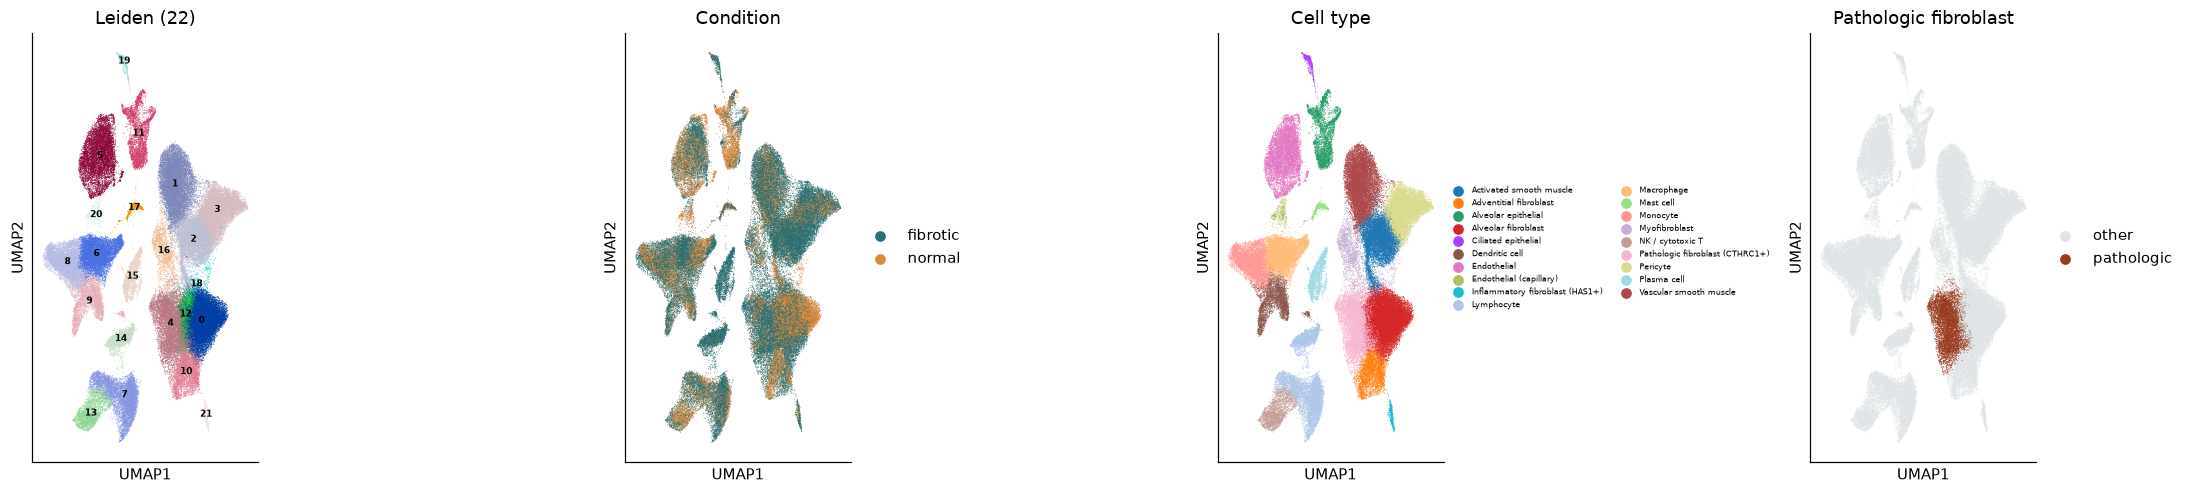

In [4]:
# UMAP: clusters, condition, and the annotated populations (+ pathologic highlighted)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
sc.pl.umap(adata, color="leiden",    ax=axes[0], show=False, legend_loc="on data", legend_fontsize=6, title="Leiden (22)")
sc.pl.umap(adata, color="condition", ax=axes[1], show=False, title="Condition", palette={"fibrotic":"#2a6f74","normal":"#d98a3d"})
sc.pl.umap(adata, color="cell_type", ax=axes[2], show=False, legend_fontsize=5, title="Cell type")
adata.obs["is_pathologic"] = (adata.obs.cell_type == PATHOLOGIC).map({True:"pathologic", False:"other"})
sc.pl.umap(adata, color="is_pathologic", ax=axes[3], show=False,
           palette={"pathologic":"#9a3b1f","other":"#dfe4e6"}, title="Pathologic fibroblast")
plt.tight_layout(); plt.show()

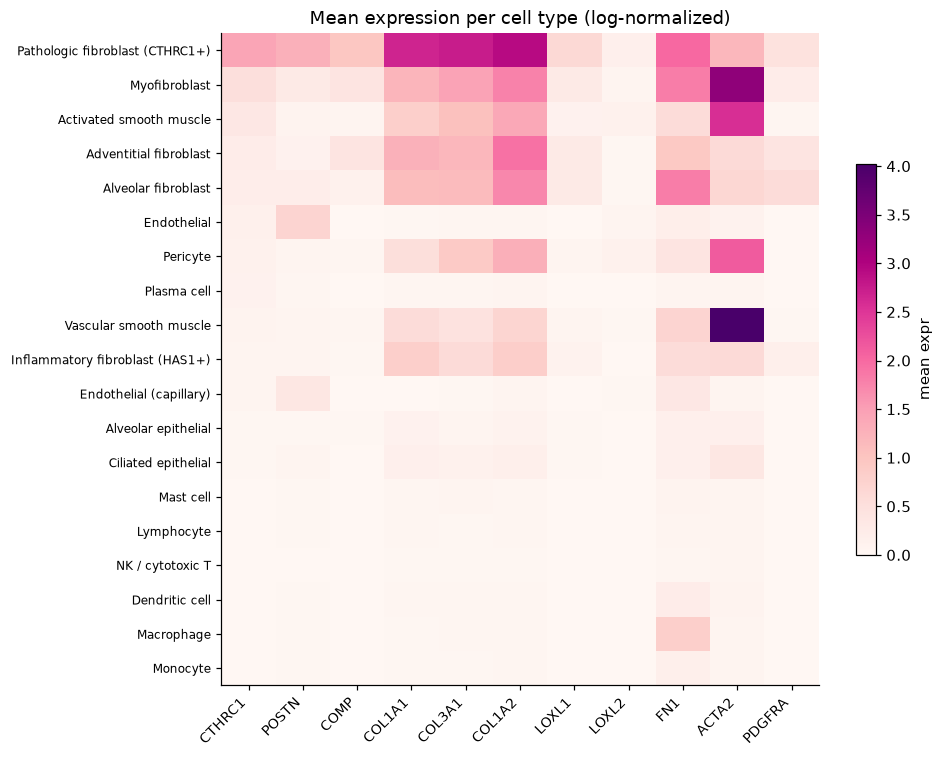

,CTHRC1,POSTN,COMP,COL1A1,COL3A1,COL1A2,LOXL1,LOXL2,FN1,ACTA2,PDGFRA
cell_type,,,,,,,,,,,
Pathologic fibroblast (CTHRC1+),1.43,1.27,0.96,2.67,2.74,2.91,0.64,0.16,2.01,1.19,0.47
Myofibroblast,0.52,0.29,0.41,1.22,1.46,1.77,0.29,0.05,1.82,3.32,0.23
Activated smooth muscle,0.34,0.09,0.05,0.81,1.07,1.39,0.12,0.13,0.58,2.58,0.04
Adventitial fibroblast,0.24,0.11,0.40,1.27,1.18,1.92,0.29,0.02,0.94,0.60,0.42
Alveolar fibroblast,0.22,0.22,0.14,1.11,1.14,1.72,0.28,0.03,1.81,0.68,0.57
Endothelial,0.15,0.71,0.00,0.03,0.03,0.05,0.00,0.06,0.20,0.10,0.01


In [5]:
# Per-cluster mean expression of pathologic / stiffening markers (cluster 4 should top the list)
genes = [g for g in ["CTHRC1","POSTN","COMP","COL1A1","COL3A1","COL1A2","LOXL1","LOXL2","FN1","ACTA2","PDGFRA"]
         if g in (adata.raw.var_names if adata.raw is not None else adata.var_names)]
expr = sc.get.obs_df(adata, keys=["cell_type"]+genes, use_raw=adata.raw is not None)
mean_by_ct = expr.groupby("cell_type", observed=True)[genes].mean()
mean_by_ct = mean_by_ct.loc[mean_by_ct["CTHRC1"].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(mean_by_ct.values, aspect="auto", cmap="RdPu", vmin=0)
ax.set_xticks(range(len(genes))); ax.set_xticklabels(genes, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(mean_by_ct))); ax.set_yticklabels(mean_by_ct.index, fontsize=8)
ax.set_title("Mean expression per cell type (log-normalized)")
fig.colorbar(im, ax=ax, shrink=.6, label="mean expr"); plt.tight_layout(); plt.show()
mean_by_ct.round(2).head(6)

**Read-out.** Pathologic fibroblast (CTHRC1⁺) sits at the top for CTHRC1, POSTN, COMP and the
collagens. The program is a continuum across
mesenchyme (pathologic > myofibroblast ≈ alveolar > adventitial > smooth muscle), so the honest
phrasing is "highest in," not "unique to." Identity is confirmed.

## 4: Result 2 - Composition: per-donor expansion in fibrosis

The correct unit is the donor, not the cell (cells within a donor are not independent). As a fraction of all cells, the pathologic signal is diluted by the heavier immune infiltrate in fibrotic donors. We compute it within the fibroblast compartment
("of this donor's fibroblasts, how many are pathologic?"). That removes the composition confound and
is the biologically meaningful ratio.

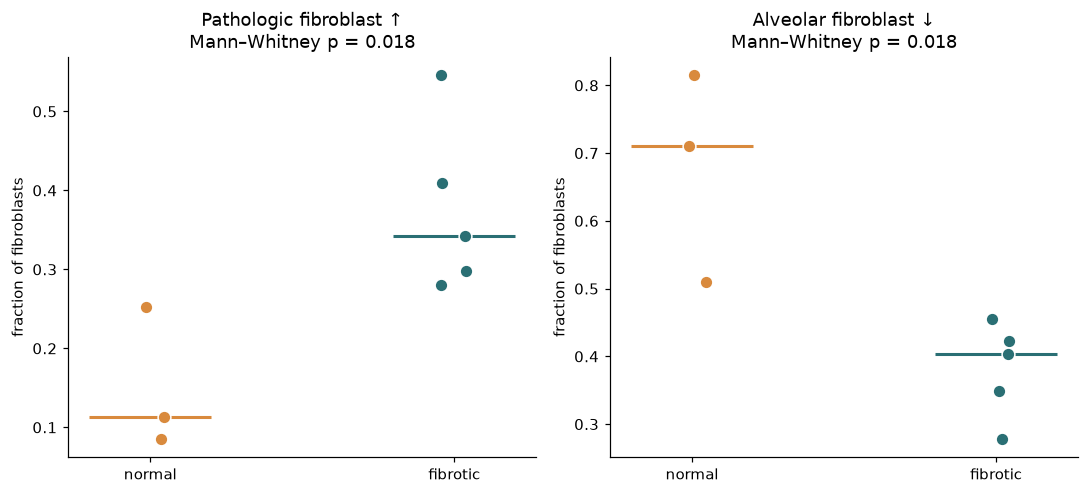

condition     fibrotic  normal
donor_id                      
IPF1             0.342     NaN
IPF2             0.281     NaN
IPF3             0.298     NaN
Normal1            NaN   0.113
Normal2            NaN   0.085
Normal3            NaN   0.252
Scleroderma1     0.546     NaN
Scleroderma2     0.410     NaN


C:\Users\olesk\AppData\Local\Temp\ipykernel_8992\3237441615.py:27: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  print(per_donor("pathologic").pivot_table(index="donor_id", columns="condition", values="frac").round(3).to_string())


In [6]:
# Per-donor fractions WITHIN the fibroblast compartment, with one-sided Mann-Whitney
obs = adata.obs
fib = obs[obs.cell_type.str.contains("fibroblast", case=False, na=False)].copy()
fib["pathologic"] = fib.cell_type.eq(PATHOLOGIC)
fib["alveolar"]   = fib.cell_type.str.contains("Alveolar", na=False)

def per_donor(col):
    return (fib.groupby(["condition","donor_id"], observed=True)[col].mean()
              .rename("frac").reset_index())

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
for ax, col, alt, ttl in [(axes[0],"pathologic","greater","Pathologic fibroblast ↑"),
                          (axes[1],"alveolar","less","Alveolar fibroblast ↓")]:
    pdv = per_donor(col)
    f = pdv[pdv.condition=="fibrotic"].frac.values
    n = pdv[pdv.condition=="normal"].frac.values
    p = mannwhitneyu(f, n, alternative=alt).pvalue
    for i,(cond,c) in enumerate([("normal","#d98a3d"),("fibrotic","#2a6f74")]):
        y = pdv[pdv.condition==cond].frac.values
        ax.scatter(np.full_like(y, i)+np.random.uniform(-.05,.05,len(y)), y, s=70, c=c, zorder=3, edgecolor="white")
        ax.hlines(np.median(y), i-.2, i+.2, color=c, lw=2)
    ax.set_xticks([0,1]); ax.set_xticklabels(["normal","fibrotic"])
    ax.set_ylabel("fraction of fibroblasts"); ax.set_title(f"{ttl}\nMann–Whitney p = {p:.3f}")
plt.tight_layout(); plt.show()

# numbers
print(per_donor("pathologic").pivot_table(index="donor_id", columns="condition", values="frac").round(3).to_string())

**Read-out.** Within the fibroblast compartment the pathologic fraction is **0.31–0.57 in fibrotic
vs 0.09–0.28 in normal (all five fibrotic donors above all three normal),
one-sided p = 0.018 (the floor at n = 5 vs 3). The reciprocal, homeostatic alveolar fibroblasts
contracting in fibrosis, separates equally cleanly (p = 0.018). During fibrosis, the
homeostatic fibroblast is replaced with the pathologic one.

## 5: Result 3 - Expression intensity: the stiffening program peaks in cluster 4

`score_genes` is relative by construction (it subtracts a matched random control set), so
scores center near zero and "high" means high versus other cells. The test is therefore which
cell type tops the ranking, and whether the score rises within the same population in disease.

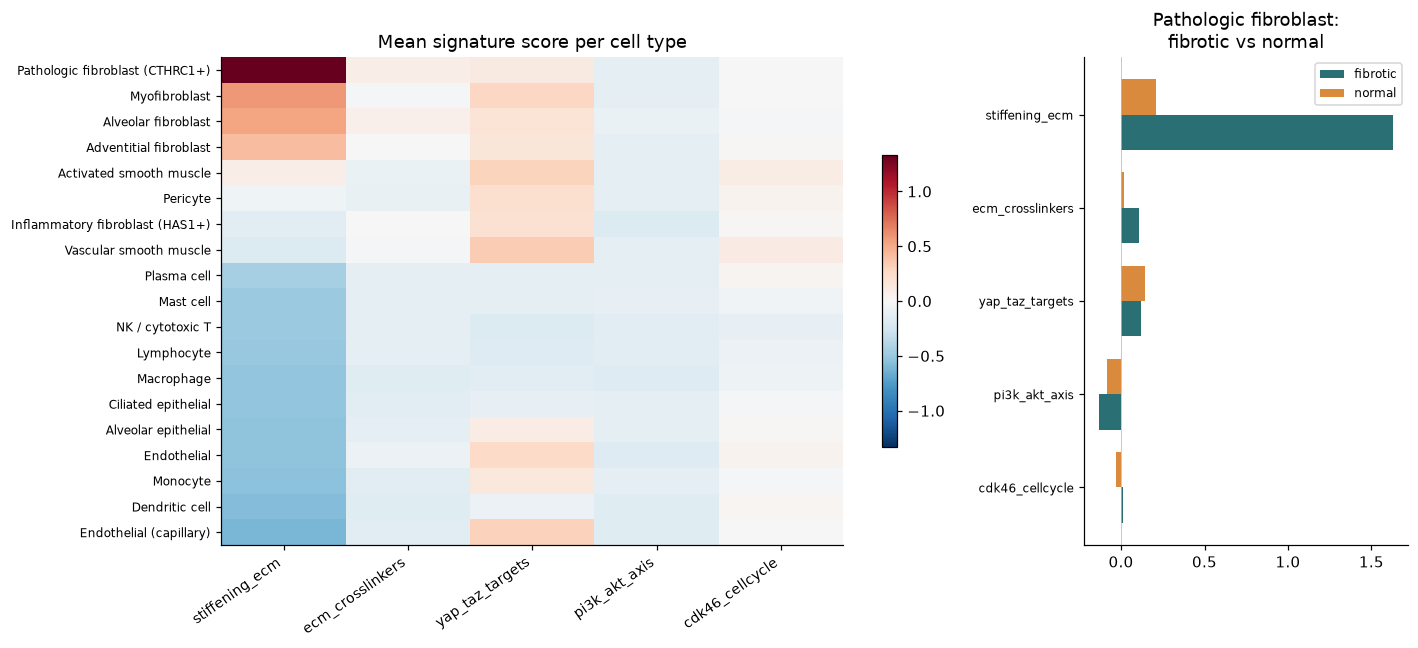

stiffening_ecm by cell type (top 4):
 cell_type
Pathologic fibroblast (CTHRC1+)    1.335
Myofibroblast                      0.577
Alveolar fibroblast                0.527
Adventitial fibroblast             0.417

pathologic fibroblast stiffening_ecm — fibrotic vs normal:
condition
fibrotic    1.631
normal      0.210


In [7]:
sig_cols = ["stiffening_ecm","ecm_crosslinkers","yap_taz_targets","pi3k_akt_axis","cdk46_cellcycle"]
M = sig_df.groupby("cell_type", observed=True)[sig_cols].mean()
M = M.loc[M["stiffening_ecm"].sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={"width_ratios":[2.4,1]})
# (left) signature x cell-type heatmap, diverging at 0
vmax = np.abs(M.values).max()
im = axes[0].imshow(M.values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[0].set_xticks(range(len(sig_cols))); axes[0].set_xticklabels(sig_cols, rotation=35, ha="right", fontsize=9)
axes[0].set_yticks(range(len(M))); axes[0].set_yticklabels(M.index, fontsize=8)
axes[0].set_title("Mean signature score per cell type"); fig.colorbar(im, ax=axes[0], shrink=.6)
# (right) within pathologic fibroblast: fibrotic vs normal
c4 = sig_df[sig_df.cell_type == PATHOLOGIC]
g = c4.groupby("condition", observed=True)[sig_cols].mean().T[["normal","fibrotic"]]
x = np.arange(len(sig_cols)); w = .38
axes[1].barh(x+w/2, g["fibrotic"], w, color="#2a6f74", label="fibrotic")
axes[1].barh(x-w/2, g["normal"],   w, color="#d98a3d", label="normal")
axes[1].set_yticks(x); axes[1].set_yticklabels(sig_cols, fontsize=8); axes[1].invert_yaxis()
axes[1].axvline(0, lw=.5, c="#bbb"); axes[1].legend(fontsize=8)
axes[1].set_title("Pathologic fibroblast:\nfibrotic vs normal")
plt.tight_layout(); plt.show()

print("stiffening_ecm by cell type (top 4):\n", M["stiffening_ecm"].round(3).head(4).to_string())
print("\npathologic fibroblast stiffening_ecm - fibrotic vs normal:")
print(c4.groupby("condition", observed=True)["stiffening_ecm"].mean().round(3).to_string())

**Read-out.** `stiffening_ecm` peaks in the pathologic fibroblast (1.34, 2x the next cell type,
10x non-mesenchyme). Within that same population it is 8x higher in fibrotic than normal cells
(1.63 vs 0.21). The niche both expands in number (Result 2) and intensifies per cell.

Two scores behaved as expected and should not be over-read. `ecm_crosslinkers` is flat because
LOXL2 is sparse at the per-cell level (it resurfaces strongly in pseudobulk, see Result 4), and
`pi3k_akt_axis` is uniformly low (AKT signaling is ubiquitous; its real test is in v2 tumor cells).

`stiffening_ecm` is built partly from collagens, and the pathologic
cluster was defined partly by collagens so this is not a fully independent validation. The clean,
non-circular evidence is the fibrotic-vs-normal contrast within the same cells (the 8× above),
which does not depend on cluster assignment.

## 6: Result 4 - Differential expression: composition vs cell-intrinsic

Per-donor pseudobulk + PyDESeq2 on the full transcriptome (not the HVG subset). Two contrasts:

- **Whole-tissue** - All cells so mixes which cells are present with what they express.
- **Fibroblast-restricted** - Fibroblast-lineage cells only. Removes the immune/epithelial
  composition confound, isolating what the fibroblast compartment does.

Comparing the two separates the two effects.

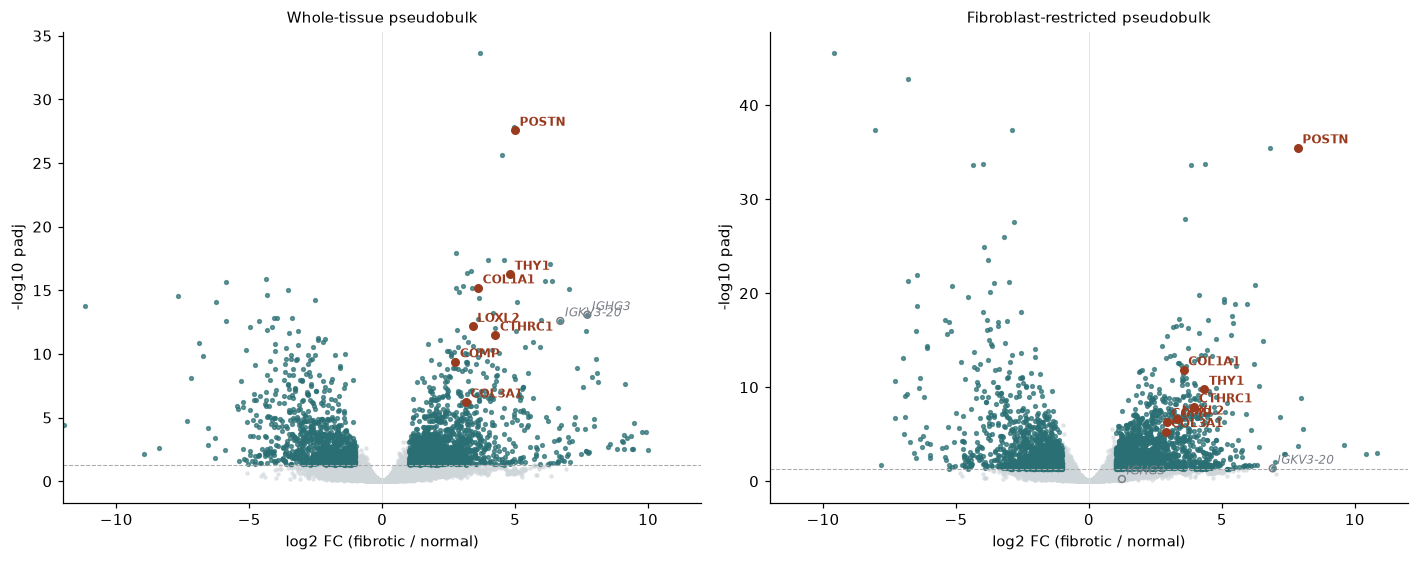

In [8]:
def volcano(ax, df, title, label_genes, drop_genes):
    d = df.dropna(subset=["padj"]).copy()
    d["nlp"] = -np.log10(d["padj"].clip(lower=1e-300))
    sig = (d["padj"] < 0.05) & (d["log2FoldChange"].abs() > 1)
    ax.scatter(d.loc[~sig,"log2FoldChange"], d.loc[~sig,"nlp"], s=4, c="#cfd6da", alpha=.5, rasterized=True)
    ax.scatter(d.loc[sig,"log2FoldChange"],  d.loc[sig,"nlp"],  s=6, c="#2a6f74", alpha=.7, rasterized=True)
    for g in label_genes:
        if g in d.index:
            ax.scatter([d.loc[g,"log2FoldChange"]],[d.loc[g,"nlp"]], s=24, c="#9a3b1f", zorder=5)
            ax.annotate(g,(d.loc[g,"log2FoldChange"],d.loc[g,"nlp"]),fontsize=8,color="#9a3b1f",
                        weight="bold",xytext=(3,3),textcoords="offset points")
    for g in drop_genes:                                   # confound genes, shown hollow
        if g in d.index:
            ax.scatter([d.loc[g,"log2FoldChange"]],[d.loc[g,"nlp"]],s=20,facecolors="none",edgecolors="#7a7f86",zorder=5)
            ax.annotate(g,(d.loc[g,"log2FoldChange"],d.loc[g,"nlp"]),fontsize=8,color="#7a7f86",
                        style="italic",xytext=(3,3),textcoords="offset points")
    ax.axhline(-np.log10(0.05), ls="--", lw=.7, c="#aaa"); ax.axvline(0, lw=.5, c="#ddd")
    ax.set_title(title, fontsize=10); ax.set_xlabel("log2 FC (fibrotic / normal)")
    ax.set_ylabel("-log10 padj"); ax.set_xlim(-12, 12)

key  = ["CTHRC1","POSTN","COL1A1","COL3A1","LOXL2","COMP","THY1"]
drop = ["IGHG3","IGKV3-20"]            # immune-infiltrate genes, expected to drop out when restricted
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
volcano(axes[0], de_w, "Whole-tissue pseudobulk",       key, drop)
volcano(axes[1], de_f, "Fibroblast-restricted pseudobulk", key, drop)
plt.tight_layout(); plt.show()

In [9]:
# Side-by-side fold-changes: confound genes collapse, activation genes persist/sharpen
rows = []
for g in ["IGHG3","IGKV3-20","CCL19","CTHRC1","POSTN","COMP","COL1A1","COL3A1","LOXL2","THY1","ACTA2"]:
    r = {"gene": g}
    for tag, d in [("whole", de_w), ("fibro", de_f)]:
        r[f"L2FC_{tag}"] = round(d.loc[g,"log2FoldChange"],2) if g in d.index else np.nan
        r[f"padj_{tag}"] = d.loc[g,"padj"] if g in d.index else np.nan
    rows.append(r)
pd.set_option("display.float_format", lambda v: f"{v:.2e}" if (abs(v)<1e-2 and v!=0) else f"{v:.2f}")
pd.DataFrame(rows).set_index("gene")

,L2FC_whole,padj_whole,L2FC_fibro,padj_fibro
gene,,,,
IGHG3,7.72,8.38e-14,1.24,0.58
IGKV3-20,6.70,2.56e-13,6.91,0.04
CCL19,5.96,2.06e-13,4.44,3.85e-05
CTHRC1,4.26,3.36e-12,3.97,1.25e-08
POSTN,5.00,2.72e-28,7.86,3.55e-36
COMP,2.75,4.20e-10,2.93,4.45e-07
COL1A1,3.61,6.56e-16,3.56,1.44e-12
COL3A1,3.15,6.09e-07,2.91,5.33e-06
LOXL2,3.40,6.89e-13,3.31,2.42e-07


**Read-out.  There are two distinct effects.**

1. Removing the composition confound: IGHG3 goes from +7.7 (padj 8e-14) whole-tissue to +1.2
  (padj 0.58) restricted. It was associated with the plasma-cell infiltrate, not the fibroblasts.
2. Cell-intrinsic activation is confirmed: every fibroblast gene holds or strengthens.
  POSTN rises from +5.0 to +7.9 (if it were only "more fibroblasts," restricting would shrink
  it. Instead it grows, so fibrotic fibroblasts individually transcribe far more). CTHRC1, COMP,
  the collagens, THY1, MMP11 stay strongly significant. LOXL2 is +3.3 (padj 2e-7), the
  crosslinker signal is fibroblast-borne. It looked absent at the sparse per-cell
  level. ACTA2 goes from non-significant to significant (the confound was hiding a
  myofibroblast signal that restriction reveals).

Fibrosis both recruits more pathologic fibroblasts (composition) and activates the
fibroblast lineage itself (intrinsic).

## 7: Caveats

- **n = 8, single cohort.**
- **Composition vs intrinsic.** Fibroblast-lineage-restricted still contains the within-fibroblast
  pathologic↔homeostatic shift, so it is "fibroblast-compartment-intrinsic," not strictly
  single-cell-intrinsic. The strictly intrinsic view is pathologic-cluster-only fibrotic-vs-normal -
  approximated by the ~8× signature gradient (Result 3).
- **Circularity** in Result 3 (signature shares collagens with the cluster definition); rely on the
  within-cell fibrotic-vs-normal contrast for the non-circular claim.
- **LOXL2 sparsity** - per-cell mean and pseudobulk see different things; the signal is real but
  only visible in aggregate.
- **Pooled etiology** - IPF + scleroderma as "fibrotic"; the scleroderma donors are noisier, and
  whether the program is IPF-specific is an open question (`disease_raw` is preserved per cell).
- **Fractional SCEA counts** rounded to integers after per-donor summing for DESeq2 (negligible at
  pseudobulk scale).
- **Sorted dataset** - mesenchyme-enriched; absolute cross-lineage proportions are not whole-tissue.
- **Annotation** mapped ≈77 % of Ensembl IDs to symbols (mygene); all signature genes resolved.

## 8: Conclusion and next steps

1. **Identity** - a discrete pathologic fibroblast (CTHRC1⁺) population, top expresser of
   CTHRC1/POSTN/COMP/collagens.
2. **Composition** - it expands in fibrosis while homeostatic alveolar fibroblasts contract;
   per-donor, complete separation, p = 0.018.
3. **Expression** - the stiffening program peaks in it (~2× next cell type) and intensifies ~8×
   in disease.
4. **Differential expression** - full-transcriptome pseudobulk confirms CTHRC1/POSTN/collagens/LOXL2
   increase; the fibroblast-restricted contrast separates compositional from cell-intrinsic activation.

This characterizes the stiff niche the dynamical model assumes in single cells, end-to-end from raw SCEA MatrixMarket files.

**v2** applies the same pipeline to NSCLC tumor data, where the flat PI3K-AKT and YAP-target scores
get their real test in malignant cells under EGFR-TKI, and the stiff-niche premise meets the cancer
arm of the model.
